# RAG 파이프라인

문서 검색 결과를 context로 구성하고 LLM 답변과 출처까지 연결하는 전체 RAG 파이프라인을 실습한다.


In [2]:
import chromadb
from dotenv import load_dotenv

from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()

EMBEDDING_MODEL_NAME = "gemini-embedding-2"
MODEL_NAME = "gemini-3.6-flash"


C:\Users\snail\AppData\Local\Temp\ipykernel_19948\1765770137.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader


### RAG Chain

RAG 파이프라인은 크게 **인덱싱 단계**와 **질의 단계**로 나뉜다.

- **인덱싱 단계**: 문서 로드 → 청킹 → 문서 임베딩 → 벡터 DB 저장
- **질의 단계**: 질문 임베딩 → 유사 문서 검색 → context 구성 → 프롬프트 입력 → LLM 답변 생성

인덱싱 단계는 문서를 검색 가능한 벡터 형태로 준비하는 과정이다. 질의 단계에서는 질문을 벡터로 변환한 뒤 의미가 유사한 청크를 검색하고, 검색 결과를 LLM이 참고할 `context`로 전달한다.

### 문서 로드 + 벡터 DB 구축

In [3]:

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

COLLECTION_NAME = "spri_ai_brief"
PERSIST_DIR = "./chroma_db"

# 문서 로드 → 분할
loader = PyPDFLoader("data/SPRi AI Brief_9월호_산업동향_0909_F.pdf")
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")

# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
existing_names = [c.name for c in client.list_collections()]
if COLLECTION_NAME in existing_names:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장 — client를 공유하여 일관된 경로 사용
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    client=client,
)

print(f"저장 완료! (컬렉션: {COLLECTION_NAME})")

총 90개 청크를 벡터 DB에 저장합니다...
저장 완료! (컬렉션: spri_ai_brief)


### 기본 RAG Chain 구성

In [4]:

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


def format_docs(docs):
    """검색된 문서 리스트를 하나의 텍스트로 합치는 함수"""
    return "\n\n".join(doc.page_content for doc in docs)


prompt = ChatPromptTemplate.from_messages([
    ("system", """너는 AI 산업 동향 전문가야. 아래 검색된 문서를 참고하여 질문에 답변해줘.
검색 결과에 없는 내용은 "해당 정보를 찾을 수 없습니다"라고 답변해.

[검색된 문서]
{context}"""),
    ("human", "{question}"),
])

# 단계별 RAG
question = "오픈AI의 차세대 모델에 대해 설명해줘"

# 1. 검색
docs = retriever.invoke(question)

# 2. 문서 포매팅
context = format_docs(docs)

chain = prompt | llm | StrOutputParser()


# 3. 프롬프트 구성 + LLM 호출
response = chain.invoke({"context": context, "question": question})

print(response)

# 출처 확인
print("\n=== 출처 ===")
for i, doc in enumerate(docs):
    print(f"  [{i+1}] 페이지 {doc.metadata.get('page', '?')}: {doc.page_content[:200]}...")


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


제공된 문서에 따른 오픈AI의 차세대 모델 **GPT-5** 및 관련 개방형 모델에 대한 주요 내용은 다음과 같습니다.

---

### 1. 차세대 모델 'GPT-5'의 주요 특징

*   **뛰어난 성능 및 심층 추론 능력:**
    *   상식과 문제 해결 능력을 평가하는 **GPQA 테스트에서 88.4%**로 최고 점수를 달성했습니다.
    *   모델 내부에 **'사고 모드(GPT-5 Thinking)'**가 탑재되어 복잡하거나 논리가 필요한 질문에 대해 자동으로 심층 추론을 수행합니다.

*   **'실시간 라우터'를 통한 최적화:**
    *   대화의 복잡성, 유형, 사용자 의도를 판단하는 **'실시간 라우터'**가 적용되었습니다.
    *   간단한 질문에는 빠르게 답하는 **경량 모드**로, 복잡한 질문에는 **사고 모드**로 알아서 전환하여 응답 시간과 품질을 최적화합니다.

*   **환각(Hallucination) 감소 및 높은 정확도:**
    *   웹 검색 활성화 조건에서 **GPT-4o 대비 사실 오류 가능성이 45% 낮고**, 사고(Thinking) 측면에서도 **o3 대비 사실 오류가 포함될 가능성이 80% 낮습니다.**
    *   실생활에 유용한 답변 제공 능력 및 창작·글쓰기 능력이 더욱 향상되었습니다.

*   **맞춤형 교육 기능 '스터디 모드':**
    *   학생의 학습 목표와 능력에 맞춰 퀴즈, 주관식 질문, 개인화 피드백을 제공합니다.
    *   교사, 과학자, 교육학 전문가와 협력하여 개발한 시스템 지침을 바탕으로 학습자의 적극적 참여, 인지 부하 관리, 메타인지 및 호기심을 유발하도록 설계되었습니다.

---

### 2. 개방형 가중치 모델 'gpt-oss' 시리즈

오픈AI는 딥시크(DeepSeek) 등 오픈소스 모델에 대응하기 위해 2025년 8월 5일, 처음으로 모델 가중치를 공개한 개방형 언어모델을 출시했습니다.

*   **gpt-oss-120b:** 단일 80GB GPU에서 작

### 하나의 Chain으로 합치기

위에서 단계별로 나눠 실행한 것을 LCEL로 하나의 chain으로 합칠 수 있다.

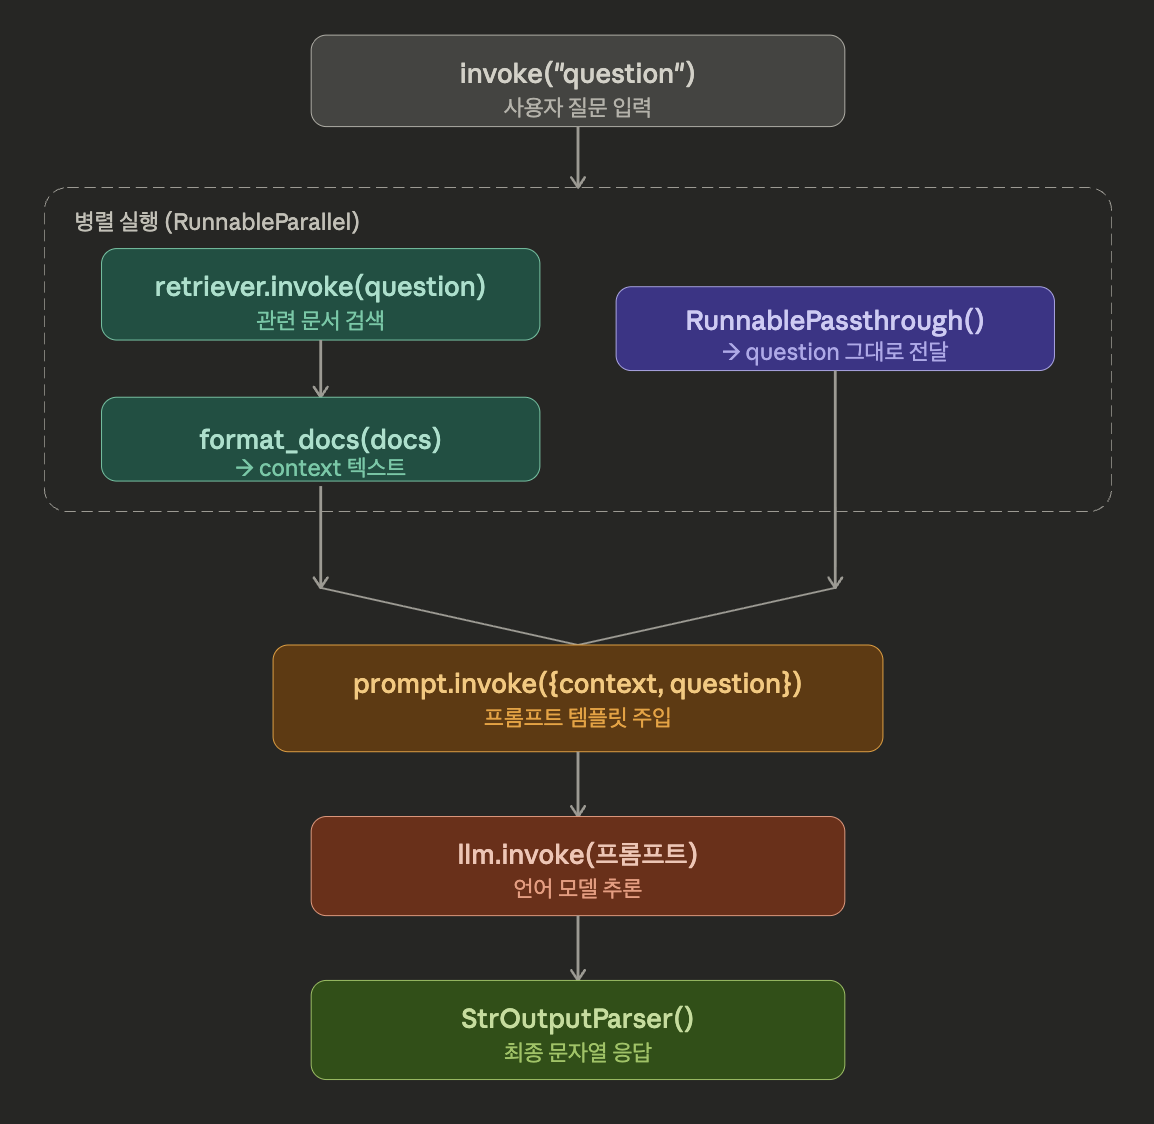

`RunnablePassthrough.assign()`은 입력 딕셔너리를 그대로 유지하면서 새로운 key를 추가한다. 여기서는 `retrieve_context()`가 `question`으로 문서를 검색하고 포매팅한 결과를 `context`로 추가한다. 그 결과 `{"question": ..., "context": ...}` 형태의 딕셔너리가 prompt에 전달된다.

#### LCEL로 파이프라인을 구성하는 이유

앞의 예제에서는 검색, 문서 포매팅, 프롬프트 구성, LLM 호출을 각각 실행했다. LCEL을 사용하면 이 단계들을 하나의 실행 가능한 파이프라인으로 조합할 수 있다.

| 구분 | 단계를 직접 호출 | LCEL 파이프라인 |
|---|---|---|
| 실행 방식 | 각 단계의 결과를 변수로 전달 | 여러 단계를 하나의 chain으로 조합 |
| 중간 값 확인 | 변수로 바로 확인하기 쉬움 | 반환 구조를 별도로 구성해야 함 |
| 비동기·스트리밍 | 각 단계에서 직접 구현 | 전체 chain에 공통 인터페이스 적용 |
| LangSmith | 호출이 별도 trace로 기록될 수 있음 | 하나의 trace에서 전체 흐름을 확인하기 쉬움 |

두 방식 중 하나만 사용해야 하는 것은 아니다. 검색 결과를 검사하거나 조건을 분기하는 부분은 함수로 작성하고, 전체 실행 흐름은 LCEL로 조합할 수 있다.

In [ ]:
# 하나의 chain으로 합치기
def retrieve_context(inputs):
    question = inputs["question"]
    docs = retriever.invoke(question)
    return format_docs(docs)


rag_chain = (
    RunnablePassthrough.assign(context=retrieve_context)
    | prompt
    | llm
    | StrOutputParser()
)

response = rag_chain.invoke(
    {"question": "오픈AI의 차세대 모델에 대해 설명해줘"}
)
print(response)


#### 딕셔너리로 Chain 입력 구성하기

Chain 안에 딕셔너리를 사용하면 각 key에 작성한 처리가 같은 입력을 받는다. 아래에서는 검색·포매팅 결과를 `context`에 담고, 원본 질문은 `RunnablePassthrough()`로 `question`에 그대로 전달한다.


In [ ]:
# 딕셔너리로 context와 question 구성
rag_chain_parallel = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm
    | StrOutputParser()
)

response = rag_chain_parallel.invoke(
    "오픈AI의 차세대 모델에 대해 설명해줘"
)
print(response)


In [ ]:
# 검색 결과에 없는 질문
response = rag_chain.invoke({"question": "삼성전자의 2024년 매출은?"})
print(response)

### 출처 표시 방식

LLM이 생성한 답변이 어떤 원본 문서에 근거하는지 사용자에게 보여주는 방식이다. 답변의 근거를 사용자가 확인하고 할루시네이션을 점검하는 데 도움이 된다.

> 출처 번호도 LLM이 생성한 결과이므로 정확성이 자동으로 보장되지는 않는다. 모델이 잘못된 번호를 표시하거나, 인용한 문서가 답변을 충분히 뒷받침하지 못할 수 있으므로 실제 문서 내용과 함께 확인해야 한다.

| 방식 | 설명 | 예시 |
|------|------|------|
| **Inline Citation** | 답변 내에 `[1]`, `[2]` 등 참조 번호 삽입 | 학술 논문 스타일 |
| **Source List** | 답변 하단에 참조 문서 목록을 별도로 표시 | Perplexity AI 스타일 |

In [ ]:
citation_prompt = ChatPromptTemplate.from_messages([
    ("system", """너는 AI 산업 동향 전문가야. 아래 검색된 문서를 참고하여 질문에 답변해줘.

규칙:
1. 답변의 각 문장 끝에 출처 번호를 [1], [2] 형태로 표시해
2. 검색 결과에 없는 내용은 절대 만들어내지 마
3. 답변할 수 없으면 "해당 정보를 찾을 수 없습니다"라고 답변해

[검색된 문서]
{context}"""),
    ("human", "{question}"),
])


def format_docs_with_index(docs):
    """문서에 번호를 붙여 포매팅한다. 페이지 번호도 함께 표시하여 LLM이 참조할 수 있게 한다."""
    return "\n\n".join(
        f"[{i+1}] (페이지 {doc.metadata.get('page', '?')}) {doc.page_content}"
        for i, doc in enumerate(docs)
    )


def citation_rag(question: str):
    """검색 → 답변 생성을 한 번에 처리하여 retriever 이중 호출을 방지한다."""
    docs = retriever.invoke(question)
    context = format_docs_with_index(docs)
    answer = (citation_prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": question}
    )
    return answer, docs


question = "AI 기업들의 최근 제품 출시 현황을 알려줘"
answer, source_docs = citation_rag(question)

print("=== 답변 (출처 포함) ===")
print(answer)

print("\n=== 참조 문서 ===")
for i, doc in enumerate(source_docs):
    print(f"  [{i+1}] (출처 : {doc.metadata.get('source', '?')}) (페이지 {doc.metadata.get('page', '?')}) {doc.page_content[:200]}...")

---

### 실습: 사내 규정 RAG 파이프라인

`data/company_rules/` 폴더의 사내 규정 문서 5개로 기본 RAG 파이프라인을 구성해보자.

### 요구사항

- `TextLoader`로 UTF-8 마크다운 파일 5개를 로드한다.
- 문서를 청킹하여 벡터 스토어에 저장한다.
- Retriever의 검색 결과를 context로 구성한다.
- 검색된 문서만 근거로 답변하고 출처를 출력한다.
- 아래 질문들로 전체 파이프라인을 테스트한다.

`TextLoader`는 마크다운 문법을 해석하지 않고 파일의 텍스트를 그대로 `Document`로 불러온다. 이 실습에서는 제목과 목록 표시를 포함한 원문을 유지한 채 청킹한다.

```text
연차는 며칠이야?
USB 꽂아서 파일 옮겨도 돼?
결혼하면 회사에서 뭘 해줘?
```

In [ ]:
# 사내 규정 마크다운 파일을 UTF-8 텍스트로 불러온다.
file_names = [
    "data/company_rules/IT지원규정.md",
    "data/company_rules/경비처리규정.md",
    "data/company_rules/보안규정.md",
    "data/company_rules/윤리규정.md",
    "data/company_rules/인사규정.md",
]

rule_documents = []
for file_name in file_names:
    loader = TextLoader(file_name, encoding="utf-8")
    rule_documents.extend(loader.load())

print(f"마크다운 문서 {len(rule_documents)}개를 불러왔습니다.")

# TODO: 불러온 문서를 청크로 분할한다.

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

COLLECTION_NAME = "company_rules"
PERSIST_DIR = "./chroma_db"

# 분할
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(rule_documents)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")



# TODO: 청크를 벡터 스토어에 저장하고 Retriever를 만든다.

client = chromadb.PersistentClient(path=PERSIST_DIR)
existing_names = [c.name for c in client.list_collections()]
if COLLECTION_NAME in existing_names:
    client.delete_collection(COLLECTION_NAME)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    client=client,
)
print(f"저장 완료! (컬렉션: {COLLECTION_NAME})")

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})





마크다운 문서 5개를 불러왔습니다.
총 42개 청크를 벡터 DB에 저장합니다...
저장 완료! (컬렉션: company_rules)
=== 답변 (출처 포함) ===


======== 질문 한 것 ========: 연차는 며칠이야?
1년간 80% 이상 출근한 직원에게는 기본적으로 15일의 연차 유급휴가가 부여됩니다 [1]. 

3년 이상 근속한 직원에게는 매 2년마다 1일의 가산 휴가가 추가로 부여됩니다 [1]. 

연차의 최대 한도는 25일입니다 [1].

=== 참조 문서 ===
  [1] (출처 : data/company_rules/인사규정.md)) ## 제4장 휴가

### 제7조 (연차 유급휴가)
1. 1년간 80% 이상 출근한 직원에게 15일의 연차 유급휴가를 부여한다.
2. 3년 이상 근속한 직원에게는 매 2년마다 1일의 가산 휴가를 추가 부여한다.
3. 연차의 최대 한도는 25일로 한다.
4. 연차는 사내 포털 시스템(portal.techstar.co.kr)에서 신청한다.
5. 3일 이상의 연...
  [2] (출처 : data/company_rules/인사규정.md)) # 인사규정

## 제1장 총칙

### 제1조 (목적)
이 규정은 회사의 인사 관리에 관한 기본 사항을 정함으로써, 공정하고 합리적인 인사 운영을 실현하는 것을 목적으로 한다. 본 규정은 2024년 1월 1일부터 시행하며, 전 임직원에게 적용된다.

### 제2조 (적용 범위)
본 규정은 정규직, 계약직, 인턴을 포함한 모든 재직자에게 적용된다. 다만, ...
  [3] (출처 : data/company_rules/인사규정.md)) ### 제4조 (수습 기간)
1. 신규 입사자에게는 3개월의 수습 기간을 적용한다.
2. 수습 기간 중 급여는 협의된 연봉의 100%를 지급한다.
3. 수습 평가는 직속 상사와 인사팀이 공동으로 실시하며, 업무 적응도, 협업 능력, 성과를 종합 평가한다.
4. 수습 기간 중 부적격 판정을 받은 경우, 1개월의 개선 기간을 부여한 후 재평가한다.
5

In [38]:
# TODO: 검색 결과를 context로 구성하여 답변과 출처를 출력한다.

citation_prompt = ChatPromptTemplate.from_messages([
    ("system", """너는 사내 규정 전문가야. 아래 검색된 문서를 참고하여 질문에 답변해줘.

규칙:
1. 답변의 각 문장 끝에 출처 번호를 [1], [2] 형태로 표시해
2. 검색 결과에 없는 내용은 절대 만들어내지 마
3. 답변할 수 없으면 "해당 정보를 찾을 수 없습니다"라고 답변해

[검색된 문서]
{context}"""),
    ("human", "{question}"),
])


def format_docs_with_index(docs):
    """문서에 번호를 붙여 포매팅한다. 페이지 번호도 함께 표시하여 LLM이 참조할 수 있게 한다."""
    return "\n\n".join(
        f"[{i+1}] ({doc.metadata.get('source', '?')}) {doc.page_content}"
        for i, doc in enumerate(docs)
    )

questions =  ["연차는 며칠이야?",
"USB 꽂아서 파일 옮겨도 돼?",
"결혼하면 회사에서 뭘 해줘?"]

print("=== 답변 (출처 포함) ===")
for question in questions:
    source_docs = retriever.invoke(question)
    context = format_docs_with_index(source_docs)

    answer = (citation_prompt | llm | StrOutputParser()).invoke({
        "context": context,
        "question": question
    })
    print(f"\n\n======== 질문 한 것 ========: {question}")
    print(answer)

    print("\n=== 참조 문서 ===")
    for i, doc in enumerate(source_docs):
        print(f"  [{i+1}] (출처 : {doc.metadata.get('source', '?')})) {doc.page_content[:200]}...")


# TODO: 세 질문으로 전체 파이프라인을 테스트한다.

=== 답변 (출처 포함) ===


======== 질문 한 것 ========: 연차는 며칠이야?
1년간 80% 이상 출근한 직원에게는 15일의 연차 유급휴가가 부여됩니다 [1]. 

또한, 3년 이상 근속한 직원에게는 매 2년마다 1일의 가산 휴가가 추가로 부여되며, 연차의 최대 한도는 25일입니다 [1].

=== 참조 문서 ===
  [1] (출처 : data/company_rules/인사규정.md)) ## 제4장 휴가

### 제7조 (연차 유급휴가)
1. 1년간 80% 이상 출근한 직원에게 15일의 연차 유급휴가를 부여한다.
2. 3년 이상 근속한 직원에게는 매 2년마다 1일의 가산 휴가를 추가 부여한다.
3. 연차의 최대 한도는 25일로 한다.
4. 연차는 사내 포털 시스템(portal.techstar.co.kr)에서 신청한다.
5. 3일 이상의 연...
  [2] (출처 : data/company_rules/인사규정.md)) # 인사규정

## 제1장 총칙

### 제1조 (목적)
이 규정은 회사의 인사 관리에 관한 기본 사항을 정함으로써, 공정하고 합리적인 인사 운영을 실현하는 것을 목적으로 한다. 본 규정은 2024년 1월 1일부터 시행하며, 전 임직원에게 적용된다.

### 제2조 (적용 범위)
본 규정은 정규직, 계약직, 인턴을 포함한 모든 재직자에게 적용된다. 다만, ...
  [3] (출처 : data/company_rules/인사규정.md)) ### 제4조 (수습 기간)
1. 신규 입사자에게는 3개월의 수습 기간을 적용한다.
2. 수습 기간 중 급여는 협의된 연봉의 100%를 지급한다.
3. 수습 평가는 직속 상사와 인사팀이 공동으로 실시하며, 업무 적응도, 협업 능력, 성과를 종합 평가한다.
4. 수습 기간 중 부적격 판정을 받은 경우, 1개월의 개선 기간을 부여한 후 재평가한다.
5. 재평가...


======== 질문 한 것 ========: USB 꽂아서 파일 옮겨도 돼?
개인 USB, 외장 하드 등 외부 저장 매체를 업무

In [39]:
## 강사님 것
# 사내 규정 마크다운 파일을 UTF-8 텍스트로 불러온다.
file_names = [
    "data/company_rules/IT지원규정.md",
    "data/company_rules/경비처리규정.md",
    "data/company_rules/보안규정.md",
    "data/company_rules/윤리규정.md",
    "data/company_rules/인사규정.md",
]

COLLECTION_NAME="company_rules"
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=50,)


rule_documents = []
for file_name in file_names:
    loader = TextLoader(file_name, encoding="utf-8")
    docs = loader.load()
    chunks = splitter.split_documents(docs)

    rule_documents.extend(chunks)

print(f"청크 {len(rule_documents)}개 완료.")

# TODO: 불러온 문서를 청크로 분할한다.

# TODO: 청크를 벡터 스토어에 저장하고 Retriever를 만든다.

# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
existing_names = [c.name for c in client.list_collections()]
if COLLECTION_NAME in existing_names:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장 — client를 공유하여 일관된 경로 사용
vectorstore = Chroma.from_documents(
    documents=rule_documents,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    client=client,
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


청크 24개 완료.


In [40]:


def format_docs_with_source(docs):
    """문서에 번호를 붙여 포매팅한다. 페이지 번호도 함께 표시하여 LLM이 참조할 수 있게 한다."""
    return "\n\n".join(
        f"[{i+1}] (source : {doc.metadata.get('source', '?').split('/')[-1]}) {doc.page_content}"
        for i, doc in enumerate(docs)
    )

# results = retriever.invoke('연차 몇개야?')

# results = format_docs_with_source(results)
# print(results)

# TODO: 검색 결과를 context로 구성하여 답변과 출처를 출력한다.
prompt = ChatPromptTemplate.from_messages([
    ("system", """주어진 <context>을 활용하여 대답해라. 
- <context>를 통해 대답할 수 없는 질문에 대해서는 "해당 정보를 찾을 수 없습니다"라고 답변해
- <context>에서 각 답변에 참고한  source의 몇조 몇항인지를 표시해. 
- <context>에 없는 내용은 절대 만들어내지마.


<context>
{context}
</context>
"""),
    ("human", "{question}"),
])
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

# TODO: 세 질문으로 전체 파이프라인을 테스트한다.

rag_chain =     {
        "context": retriever | format_docs_with_source,
        "question": RunnablePassthrough(),
    } | prompt | llm | StrOutputParser()



In [45]:
for q in ["연차는 며칠이야?","개인 USB 연결해도 되나?","결혼하면 회사에서 뭘 해줘?"]:
    print(rag_chain.invoke(q))
    print()

연차 유급휴가는 다음과 같이 규정되어 있습니다.

1. **기본 연차:** 1년간 80% 이상 출근한 직원에게 **15일**이 부여됩니다. (인사규정.md 제7조 제1항)
2. **가산 휴가:** 3년 이상 근속한 직원에게는 매 2년마다 **1일**의 가산 휴가가 추가 부여됩니다. (인사규정.md 제7조 제2항)
3. **최대 한도:** 연차의 최대 한도는 **25일**입니다. (인사규정.md 제7조 제3항)

개인 USB, 외장 하드 등 외부 저장 매체의 업무용 PC 연결은 금지되어 있습니다. (참고: 보안규정.md 제7조 제2항)

회사에서 결혼과 관련하여 지원하는 내역은 다음과 같습니다.

1. **본인 결혼**
   - **경조금 및 화환 지원:** 축의금 20만원과 화환이 지급됩니다. (경비처리규정.md 제14조 제1항)
   - **특별 휴가:** 유급 휴가 5일이 부여됩니다. (인사규정.md 제8조 제1항)

2. **자녀 결혼**
   - **특별 휴가:** 유급 휴가 1일이 부여됩니다. (인사규정.md 제8조 제2항)

경조사 발생 시 인사팀에 신고하면 경조금과 특별 휴가가 함께 처리됩니다. (경비처리규정.md 제14조 제5항)

